In [1]:
from HARey.harey_main import HAReyMain
from HARey.projections import local2polarmap, stereo_polar, azimuthal_polar, stereo_radius, azimuthal_radius
import matplotlib.pyplot as plt
import numpy as np

harey = HAReyMain()

Using the style file : /home/menegattig/Desktop/HARey_constellations_cards/HARey/default_style.yaml


Loading constellations diagrams....     Done!
Loading star coordinates....     Done!
Computing stars colors...     Done!
Loading custom markers....       Done!
Loading the object names....       Done!
Loading the milky way shape....       Done!


Using the tarot format, 2.75x4.75 in, using the template at /home/menegattig/Desktop/HARey_constellations_cards/HARey/cardbacks/tarot_round.png.


# Astrolabes and planispheres

The astrolabe is one of the oldest astronomical insteruments, dating back to the classic antiquity. It served as star chart showing the visible half-dome of the sky, and to measure angles.

It was born as a flat projection of the armillary sphere, a globe toy model of the sky made from metal rings (_armillae_ in latin). The rings were used to create all the great circles used in astronomy: the horizon and the North-South meridian of the local observer made up the _local globe_; the celestial equator, the celestial tropics and the ecliptic made the _sky globe_. The celestial globe could rotate around its axis like the real sky and it could be inclined inside of the local globe to simulate the sky seen from an observer at a different latitude. 

## The Mater and the Rete

The astrolabe was the pocket version of the armillary sphere, a flat disk made by looking at the armillary sphere from the celestial poles and projecting both the sky globe and the local globe on flats disks.

The _local disk_, called __Mater__, represents the sky seen by the observer, with the cardinal directions, the local horizon and the zenith point. It also showed meridians and _almucantarats_ as a grid to compute azimuth and elevation. Sometimes the _mater_ was interchangeable with others made for different latitudes, so the same instrument could be carried around.

The _sky disk_, called __Rete__, represents instead the celestial reference frame, showing the position of stars and the ecliptic. This polar map is the same for every planisphere and shows the northern or southern clestial hemisphere. This was made by thin metal stripes (hence the name _rete_, latin for _net_) to make possible to see the _mater_ below it. It usually showed only the ecliptic ring and the position of few bright stars.

Ancient astrolabes were made out of copper or bronze and were rigthfully considered artpieces. Modern astrolabes, called planispheres, put the _rete_ below the _mater_, the first a rich and detailed celestial map showing all of the stars and constellations, while the latter becomes a simple cutout shape for the horizon, and are used only to show which stars are visible at a given date and time.

## How an astrolabe work

The astrolabe/planispere (I will use either terms) works thanks to the fact that the two disks can rotate around the celestial poles, exactly as the Earth does around its axis. 

We will consider the Earth as fixed with the sky rotating: the _mater_ will show the local horizon and the cardinal points, and the _rete_ will rotate together with the sky. The astrolabe is to be held above your head as you look at the sky, so the cardinal points East and West are switched and not what they look like in everyday maps. 

The _rete_ rotates with the stars completing a full rotation is a little less than 24 hours, moving counterclockwise (for an observer in the northern hemisphere), with the hour written on the border of the _mater_, like a strange clock. As the stars in reality take around 23 hours and 56 minutes (called a _sideral day_, instead of the _mean solar day_ of exactly 24 hours) so each _solar_ day the _rete_ completes a little more than a full turn. This difference is accounted for on the calendar printed on the border of the _rete_, which moves clockwise each day: as the _rete_ does a full turn turn in 24 hours as seen from the _mater_, advancing one day will account for the extra rotation of the skies. 

__To sum up__: to use an astrolabe, align the current time on the _mater_ with the current day on the _rete_, look upwards and the sky above you is exactly the same displayed in the astrolabe.

A few caveats to the use of the astrolabe, going from bigger to smaller:
- The hour displayed on the astrolabe is the _local mean solar time_. Some countries, from the last Sunday of March to the last of October will switch to __Daylight saving time__, advancing the clocks one hour forward to better use the daytime. During this period, set the hour on the astrolabe __one hour less__ than the one that shows up on your watch.

- The _local_ in _local mean solar time_ means that the astrolabe uses your local time which depends on your longitude, not the longitude of your time zone fuse. This difference in time, 4 minutes for degree of longitude difference, could be small, but it can also completely change your results. Luckily, it can be accounted for by offsetting the hour ring when printing your astrolabe.

- Finally, the _rete_ should also account for the fact that the difference between _solar day_ and _celestial day_ requires 365.24 days to realign the two days, which is why leap years are introduced once every 4 years to make sure that the difference between the two times, _solar day_ time and _celestial day_ time, do not grow constantly. This would require not one calendar ring, but 4, one for each year, each shifted a little compared to the one before. But because this error in aligning the day is below 4 minutes, only one calendar ring is present, and leap years are forgotten.

- ...due the equinox precession, the celestial coordinates of all stars in the rete will change with a rate of about 1° each century, so your _rete_ won't be used by our great-great-great_grandkids, but at this point, who cares anymore...

The only two errors that you should correct are the first two. And remember that the astrolabe is not an _absolutely_ precise instrument.

## A matter of projections

The historical stereographic projection preserves shapes and make it possible to create a Mater only with compass, ruler, and very little trigonometry, but for latitudes close to the equator the projection on the mother becomes so distant from the center that a very large FOV for the rete is needed to cover the constellations that are close to the horizon. 

The required FOV is $2(180° - abs(lat))$: for this reason almost every astrolabe does not cover the whole celestial dome, and astrolabes do not work near the equator. Also the stereographic projection creates consellations that are smaller and smaller towards the center, making distinguish features difficult.

The more recent planispheres were created to circumvent this problem: they are astrolabes which use an azimuthal projection. This does not grow as fast as the stereographic does, but this comes with the cost of more distorted costellations. Also, the projection can't be done with comapss and ruler alone.

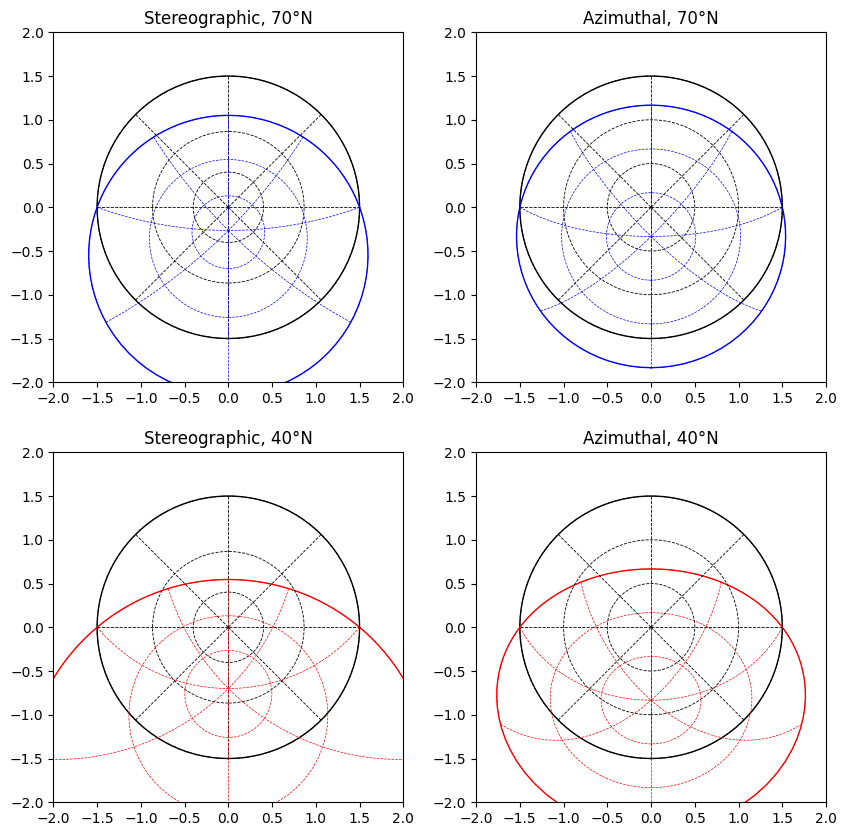

In [2]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(figsize=(10,10), nrows=2, ncols=2)

lat1 = 70
lat2 = 40

phi = np.linspace(0,360,100)
theta = np.full(100,0)

stereo_r = stereo_radius(180)
stereo_scale = 1.5/stereo_r
x,y = stereo_polar(phi, theta)
ax1.plot(stereo_scale*x, stereo_scale*y, 'k', lw=1)
ax3.plot(stereo_scale*x, stereo_scale*y, 'k', lw=1)

azimuth_r = azimuthal_radius(180)
azimuth_scale = 1.5/azimuth_r

x,y = azimuthal_polar(phi, theta)
ax2.plot(azimuth_scale*x, azimuth_scale*y, 'k', lw=1)
ax4.plot(azimuth_scale*x, azimuth_scale*y, 'k', lw=1)

x,y = local2polarmap(phi, theta, lat1, mode='stereo')
ax1.plot(stereo_scale*x, stereo_scale*y, 'b', lw=1)

x,y = local2polarmap(phi, theta, lat1, mode='azimuth')
ax2.plot(azimuth_scale*x, azimuth_scale*y, 'b', lw=1)

x,y = local2polarmap(phi, theta, lat2, mode='stereo')
ax3.plot(stereo_scale*x, stereo_scale*y, 'r', lw=1)

x,y = local2polarmap(phi, theta, lat2, mode='azimuth')
ax4.plot(azimuth_scale*x, azimuth_scale*y, 'r', lw=1)  

for i in range(0,90,30):
    
    theta = np.full(100,i)

    x,y = stereo_polar(phi,theta)
    ax1.plot(stereo_scale*x, stereo_scale*y, 'k--', lw=0.6)
    ax3.plot(stereo_scale*x, stereo_scale*y, 'k--', lw=0.6)

    x,y = azimuthal_polar(phi,theta)
    ax2.plot(azimuth_scale*x, azimuth_scale*y, 'k--', lw=0.6)
    ax4.plot(azimuth_scale*x, azimuth_scale*y, 'k--', lw=0.6)

    x,y = local2polarmap(phi, theta, lat1, mode='stereo')
    ax1.plot(stereo_scale*x, stereo_scale*y, 'b--', lw=0.5)

    x,y = local2polarmap(phi, theta, lat1, mode='azimuth')
    ax2.plot(azimuth_scale*x, azimuth_scale*y, 'b--', lw=0.5)

    x,y = local2polarmap(phi, theta, lat2, mode='stereo')
    ax3.plot(stereo_scale*x, stereo_scale*y, 'r--', lw=0.5)

    x,y = local2polarmap(phi, theta, lat2, mode='azimuth')
    ax4.plot(azimuth_scale*x, azimuth_scale*y, 'r--', lw=0.5)  

for i in range(0,360,45):
    
    phi = np.full(100,i)
    theta = np.linspace(0,90,100)

    x,y = stereo_polar(phi,theta)
    ax1.plot(stereo_scale*x, stereo_scale*y, 'k--', lw=0.6)
    ax3.plot(stereo_scale*x, stereo_scale*y, 'k--', lw=0.6)

    x,y = azimuthal_polar(phi,theta)
    ax2.plot(azimuth_scale*x, azimuth_scale*y, 'k--', lw=0.6)
    ax4.plot(azimuth_scale*x, azimuth_scale*y, 'k--', lw=0.6)

    x,y = local2polarmap(phi, theta, lat1, mode='stereo')
    ax1.plot(stereo_scale*x, stereo_scale*y, 'b--', lw=0.5)

    x,y = local2polarmap(phi, theta, lat1, mode='azimuth')
    ax2.plot(azimuth_scale*x, azimuth_scale*y, 'b--', lw=0.5)

    x,y = local2polarmap(phi, theta, lat2, mode='stereo')
    ax3.plot(stereo_scale*x, stereo_scale*y, 'r--', lw=0.5)

    x,y = local2polarmap(phi, theta, lat2, mode='azimuth')
    ax4.plot(azimuth_scale*x, azimuth_scale*y, 'r--', lw=0.5)   

for ax in (ax1,ax2,ax3,ax4):
    ax.set_xlim(-2,2)
    ax.set_ylim(-2,2)
    ax.set_aspect('equal')

ax1.set_title('Stereographic, 70°N')
ax2.set_title('Azimuthal, 70°N')
ax3.set_title('Stereographic, 40°N')
ax4.set_title('Azimuthal, 40°N')


plt.show()

In the plot are shown the mater and rete (in black) for different projections at different latitudes. The solid line represent the 0° parallel, which is the local horizon on the mater and the celestial equator on the rete. The plot shows as the latitude goes towars the equator, the projected horizon grows bigger and requires a bigger rete to completely encompass it. The azimuthal projection limits the mater size, but at the cost of more distortion.

The Field Of View parameter used in the plots is the angular size of the rete. The required FOV to completely cover up the sky seen by the observer is $2(180°-|lat|)$. For an observer at $45°$, the required FOV is $270°$, which introduces a lot of distortion in an azimuthal map and makes a stereographic projection unusable, so usually the FOV is lowered and a part of the sky left uncovered.

Recently, two-sided planispheres have been introduced, which project the mater from both poles. In this way the FOV required to see the whole sky is just 180°, plus a bit more to have an overlap between the views. In this way planispheres work also near the equator.

In the following plot, the _mater front_ represents is the projection of the local sky dome from the closest pole and the _mater back_ is the projection from the opposite pole.

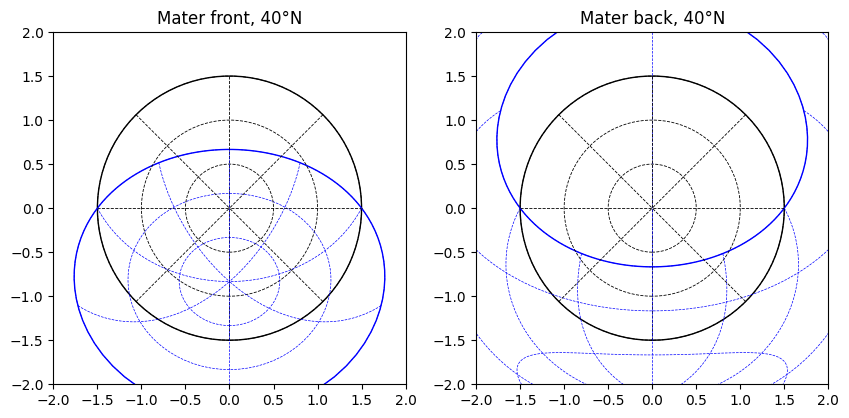

In [3]:
fig, (ax1,ax2) = plt.subplots(figsize=(10,10), nrows=1, ncols=2)

lat1 = 40

phi = np.linspace(0,360,100)
theta = np.full(100,0)

azimuth_r = azimuthal_radius(180)
azimuth_scale = 1.5/azimuth_r

x,y = azimuthal_polar(phi, theta)
ax1.plot(azimuth_scale*x, azimuth_scale*y, 'k', lw=1)
ax2.plot(azimuth_scale*x, azimuth_scale*y, 'k', lw=1)

x,y = local2polarmap(phi, theta, lat1, mode='azimuth', pole='N')
ax1.plot(azimuth_scale*x, azimuth_scale*y, 'b', lw=1)

x,y = local2polarmap(phi, theta, lat1, mode='azimuth', pole='S')
ax2.plot(azimuth_scale*x, azimuth_scale*y, 'b', lw=1)

for i in range(0,90,30):
    
    theta = np.full(100,i)

    x,y = azimuthal_polar(phi,theta)
    ax1.plot(azimuth_scale*x, azimuth_scale*y, 'k--', lw=0.6)
    ax2.plot(azimuth_scale*x, azimuth_scale*y, 'k--', lw=0.6)

    x,y = local2polarmap(phi, theta, lat1, mode='azimuth', pole='N')
    ax1.plot(azimuth_scale*x, azimuth_scale*y, 'b--', lw=0.5)

    x,y = local2polarmap(phi, theta, lat2, mode='azimuth', pole='S')
    ax2.plot(azimuth_scale*x, azimuth_scale*y, 'b--', lw=0.5)  

for i in range(0,360,45):
    
    phi = np.full(100,i)
    theta = np.linspace(0,90,100)

    x,y = azimuthal_polar(phi,theta)
    ax1.plot(azimuth_scale*x, azimuth_scale*y, 'k--', lw=0.6)
    ax2.plot(azimuth_scale*x, azimuth_scale*y, 'k--', lw=0.6)

    x,y = local2polarmap(phi, theta, lat1, mode='azimuth', pole='N')
    ax1.plot(azimuth_scale*x, azimuth_scale*y, 'b--', lw=0.5)

    x,y = local2polarmap(phi, theta, lat2, mode='azimuth', pole='S')
    if not i==180:
        ax2.plot(azimuth_scale*x, azimuth_scale*y, 'b--', lw=0.5)   

for ax in (ax1,ax2):
    ax.set_xlim(-2,2)
    ax.set_ylim(-2,2)
    ax.set_aspect('equal')

ax1.set_title('Mater front, 40°N')
ax2.set_title('Mater back, 40°N')


plt.show()

## How to make a planisphere

To make a planisphere (or astrolabe, depending on the projection you will use) you will need glue, scissors and cardboard and a paper fastener to join the Mater and the Rete together in the center. Usually the Mater is printed on transparent plastic to make the stars below visible, but different ways to do this exist. The option __MARK_CENTER__ marks with an x where the center of the plot is. 

The HARey module constains the functions __create_planisphere()__ and __create_planisphere_2sided()__ to create Maters and polar maps with the same size.

The FOV of the polar map required to see the whole sky inside the Mater with a one-side planisphere is $2(180°-|lat|)$, but you will likely have to use a smaller value as high FOVs make the map unreadable. The default projection is azimuthal: a stereo projection preserves better the shape of the constellations, but is considerably worse for high FOVs.

For two-side planispheres, the FOV is 190°-200° and both projections work fine.

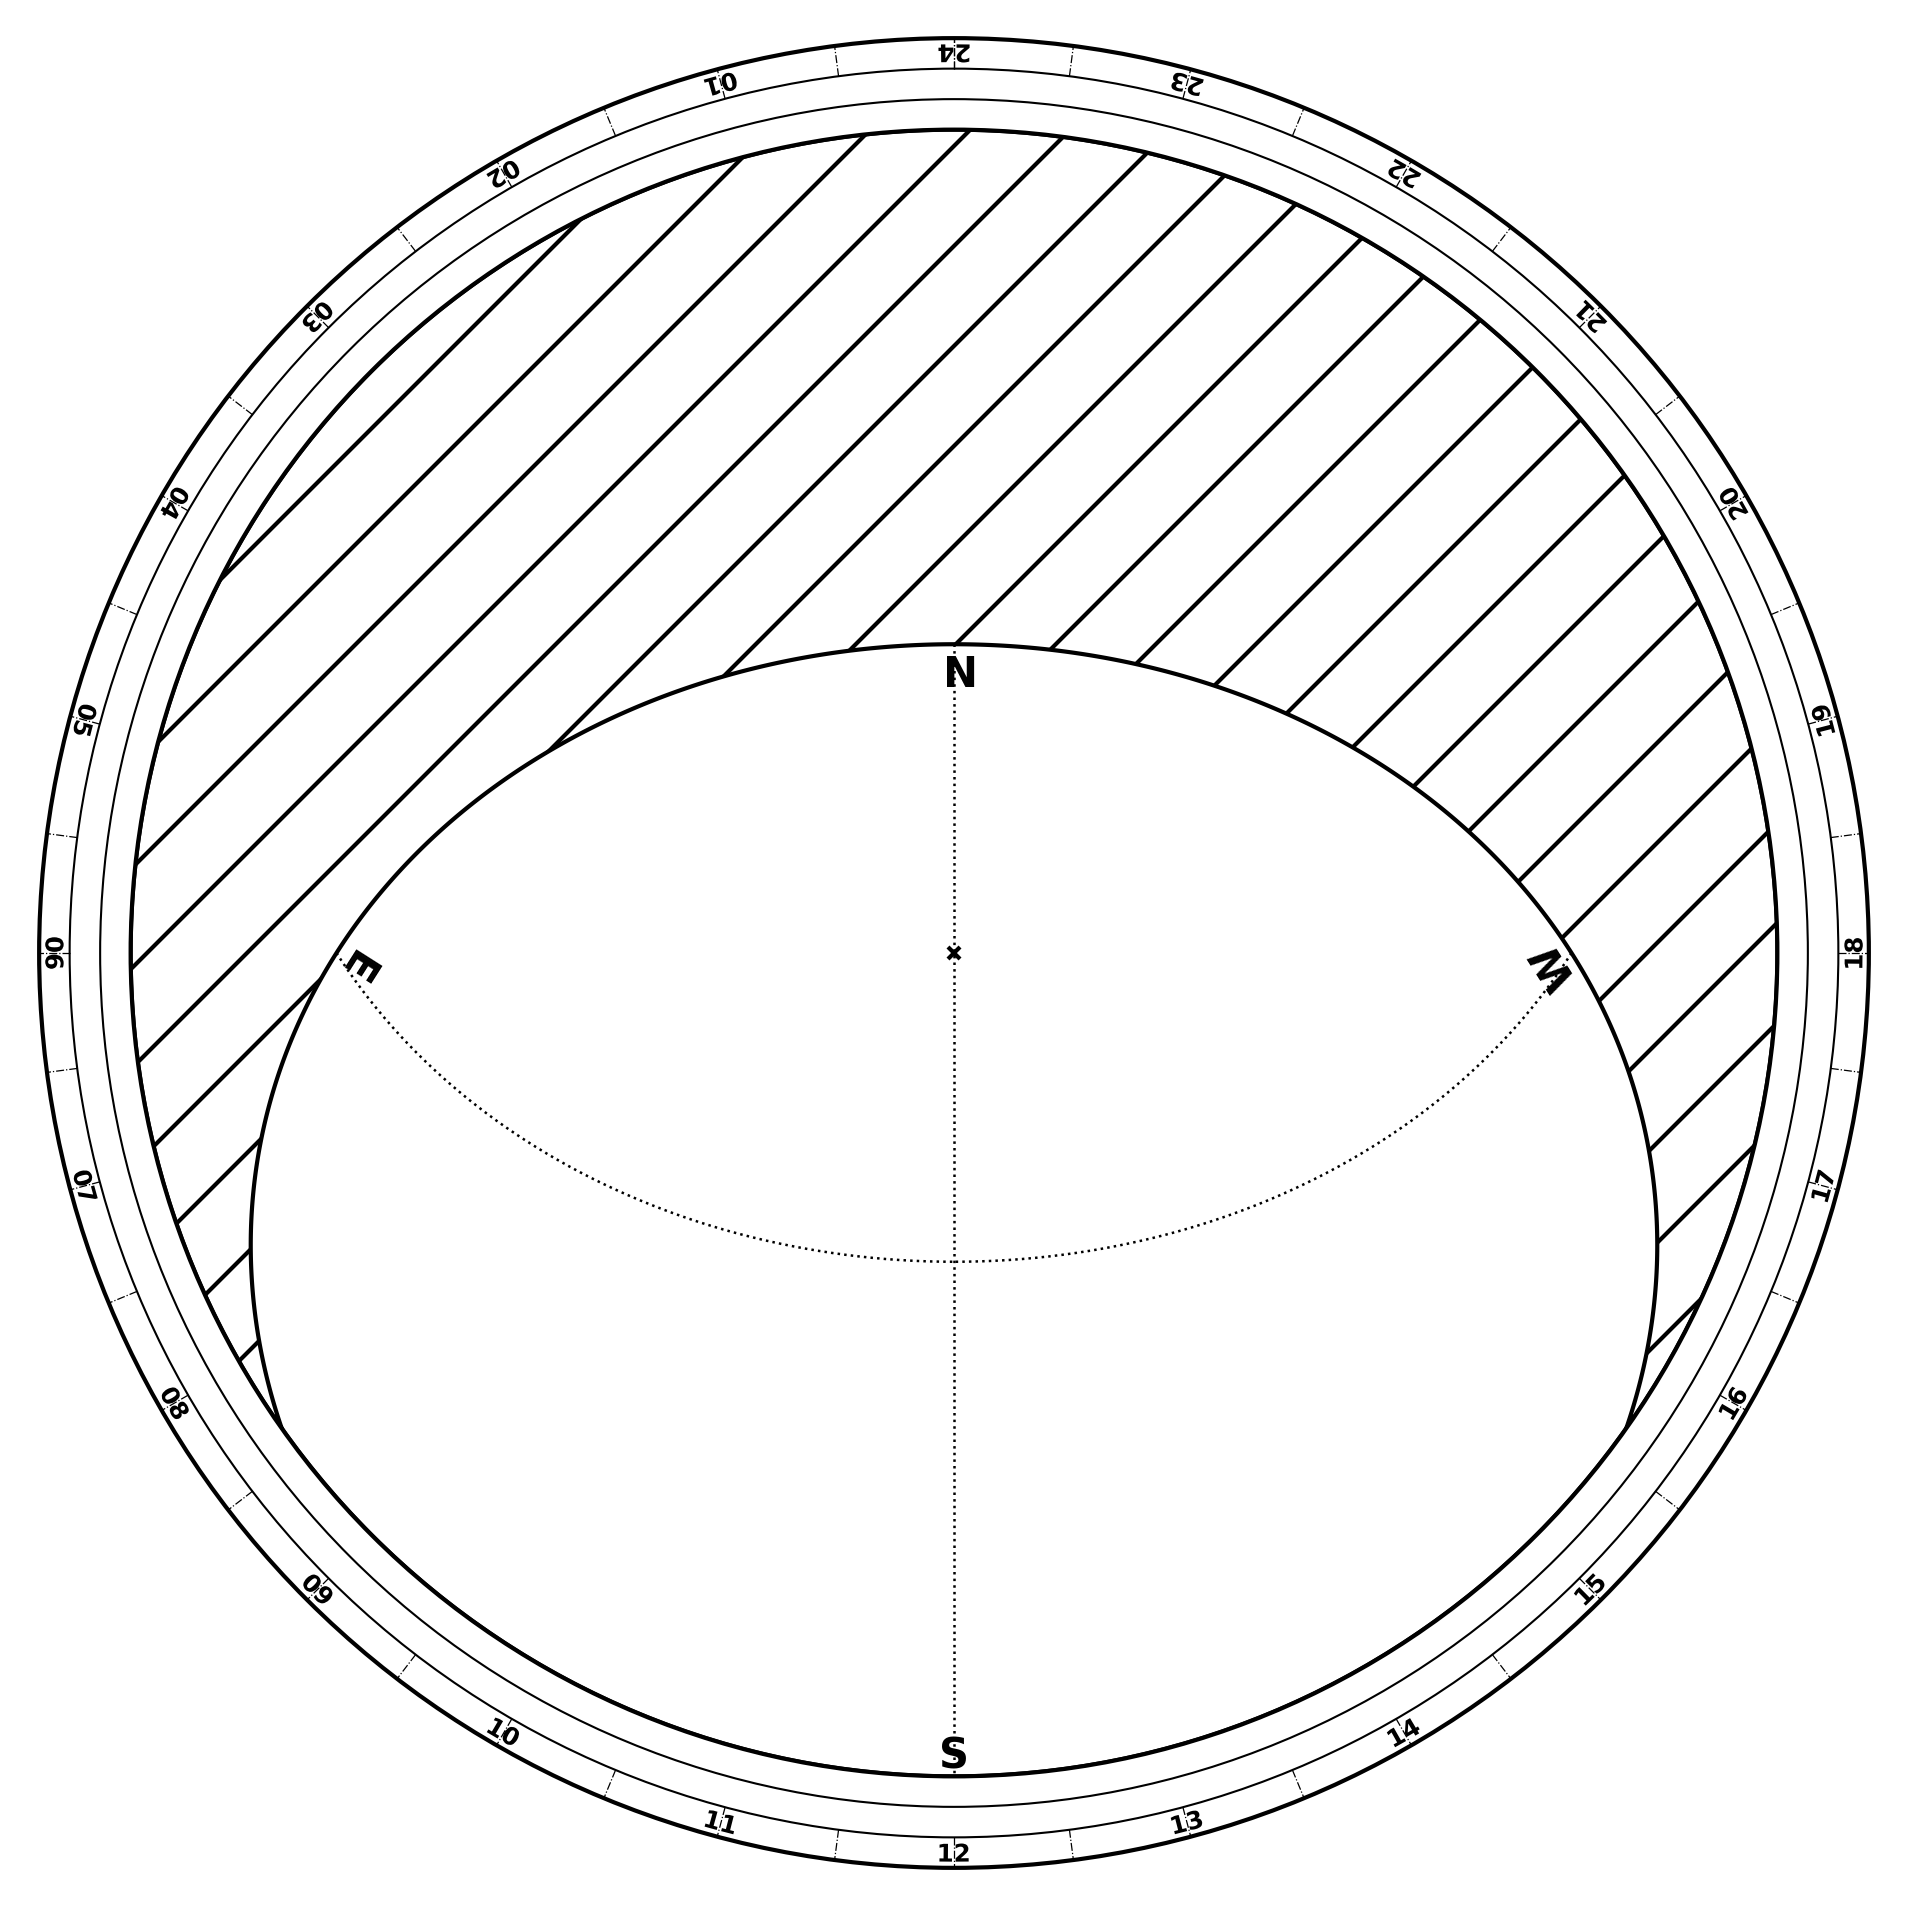

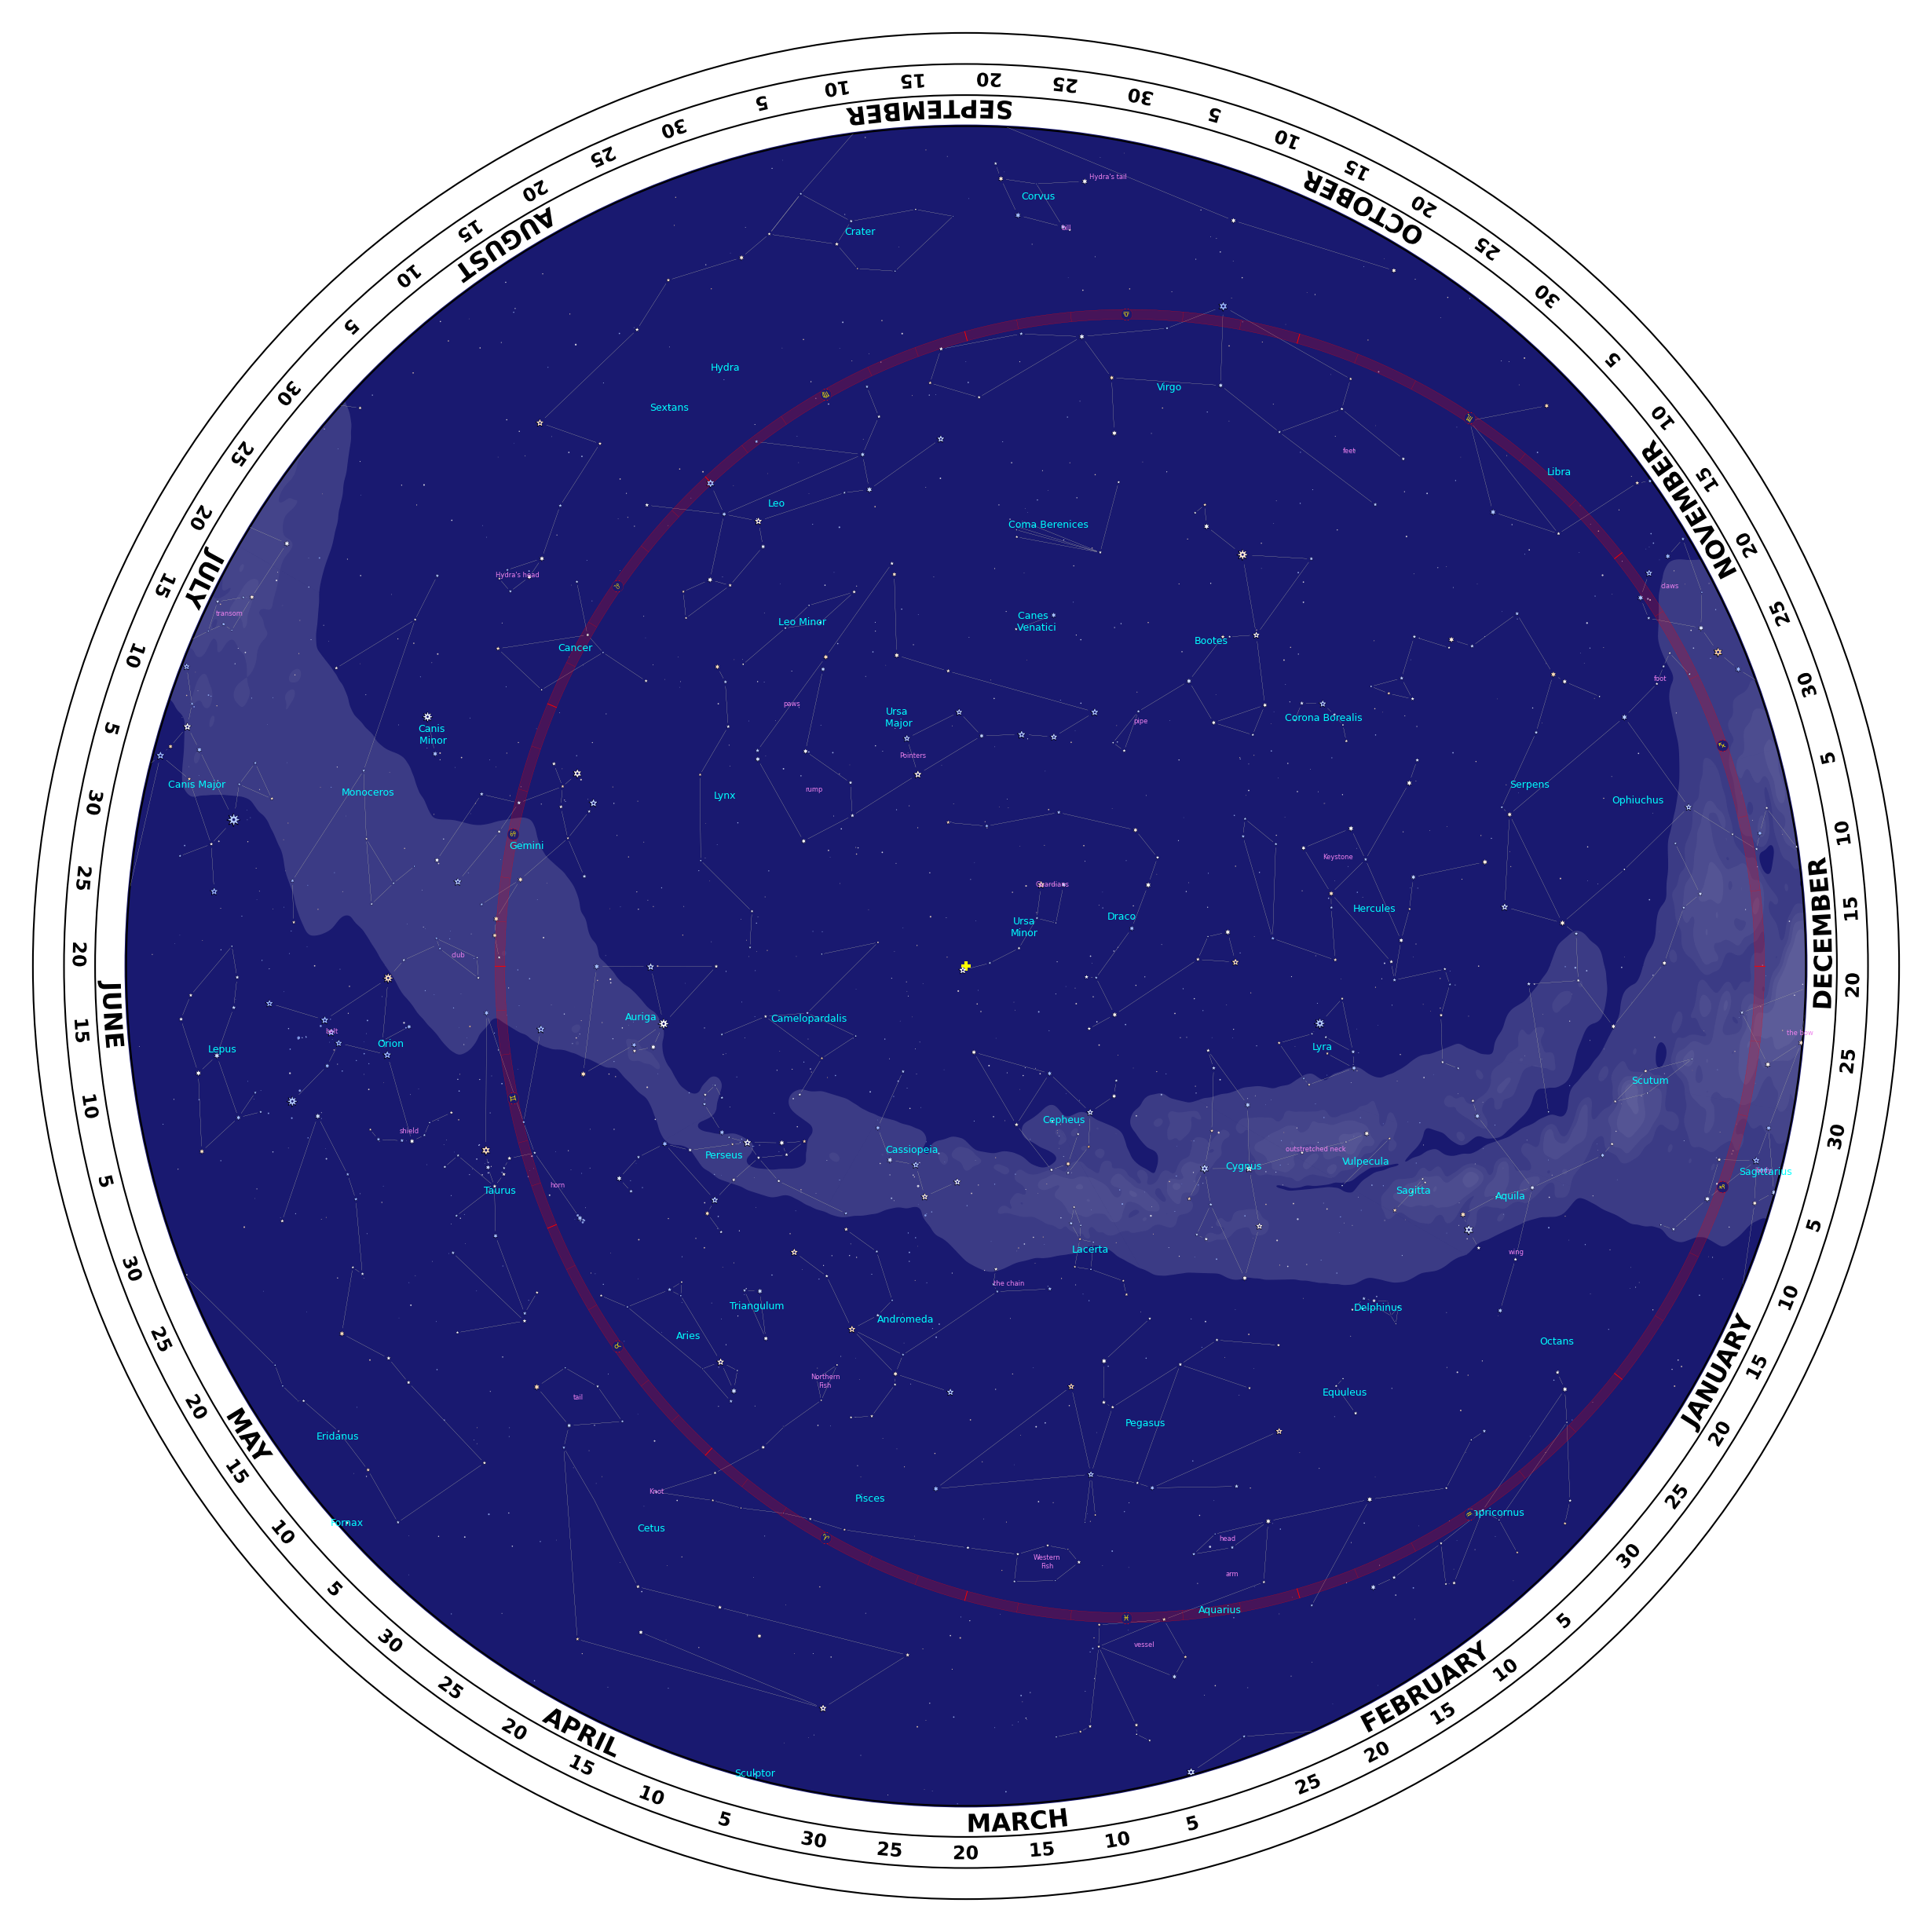

In [5]:
flags = ('con_lines', 'star_colors', 'con_names')
harey.create_planisphere(lat = '45 N', FOV=240, save_folder='planisphere', mode='azimuth', *flags)

And now a two sided planisphere, to use at 30° S:

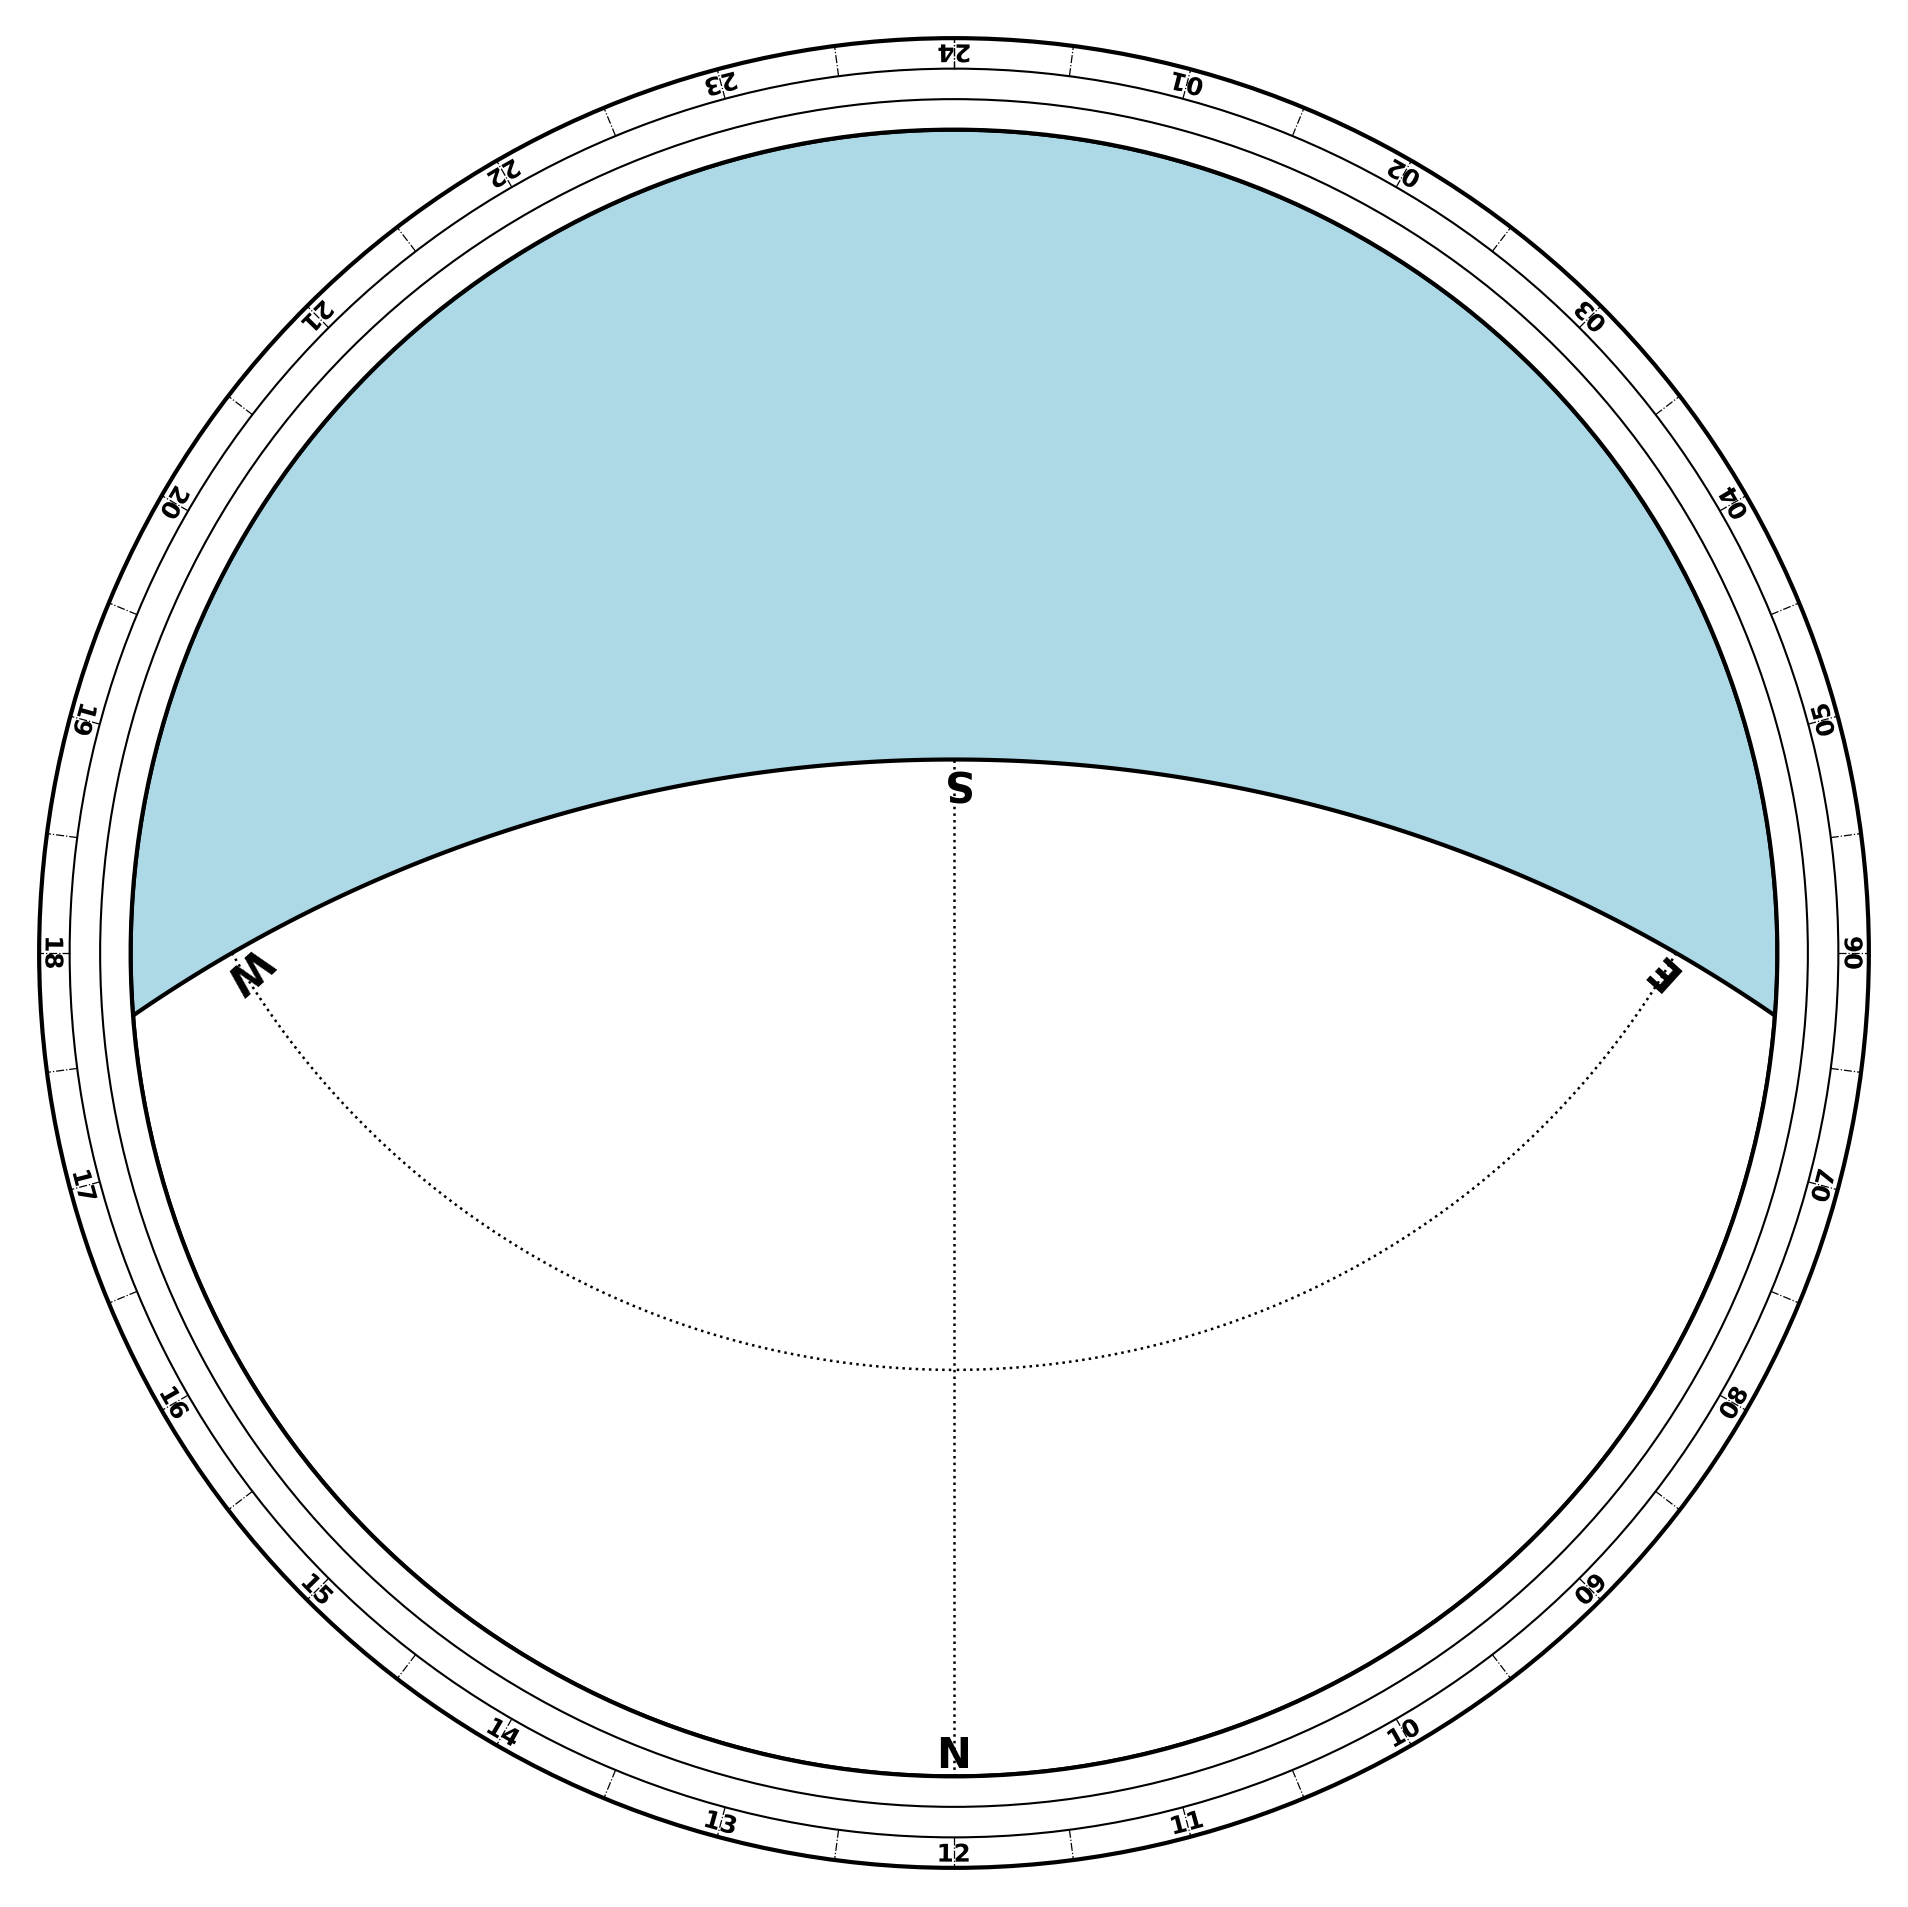

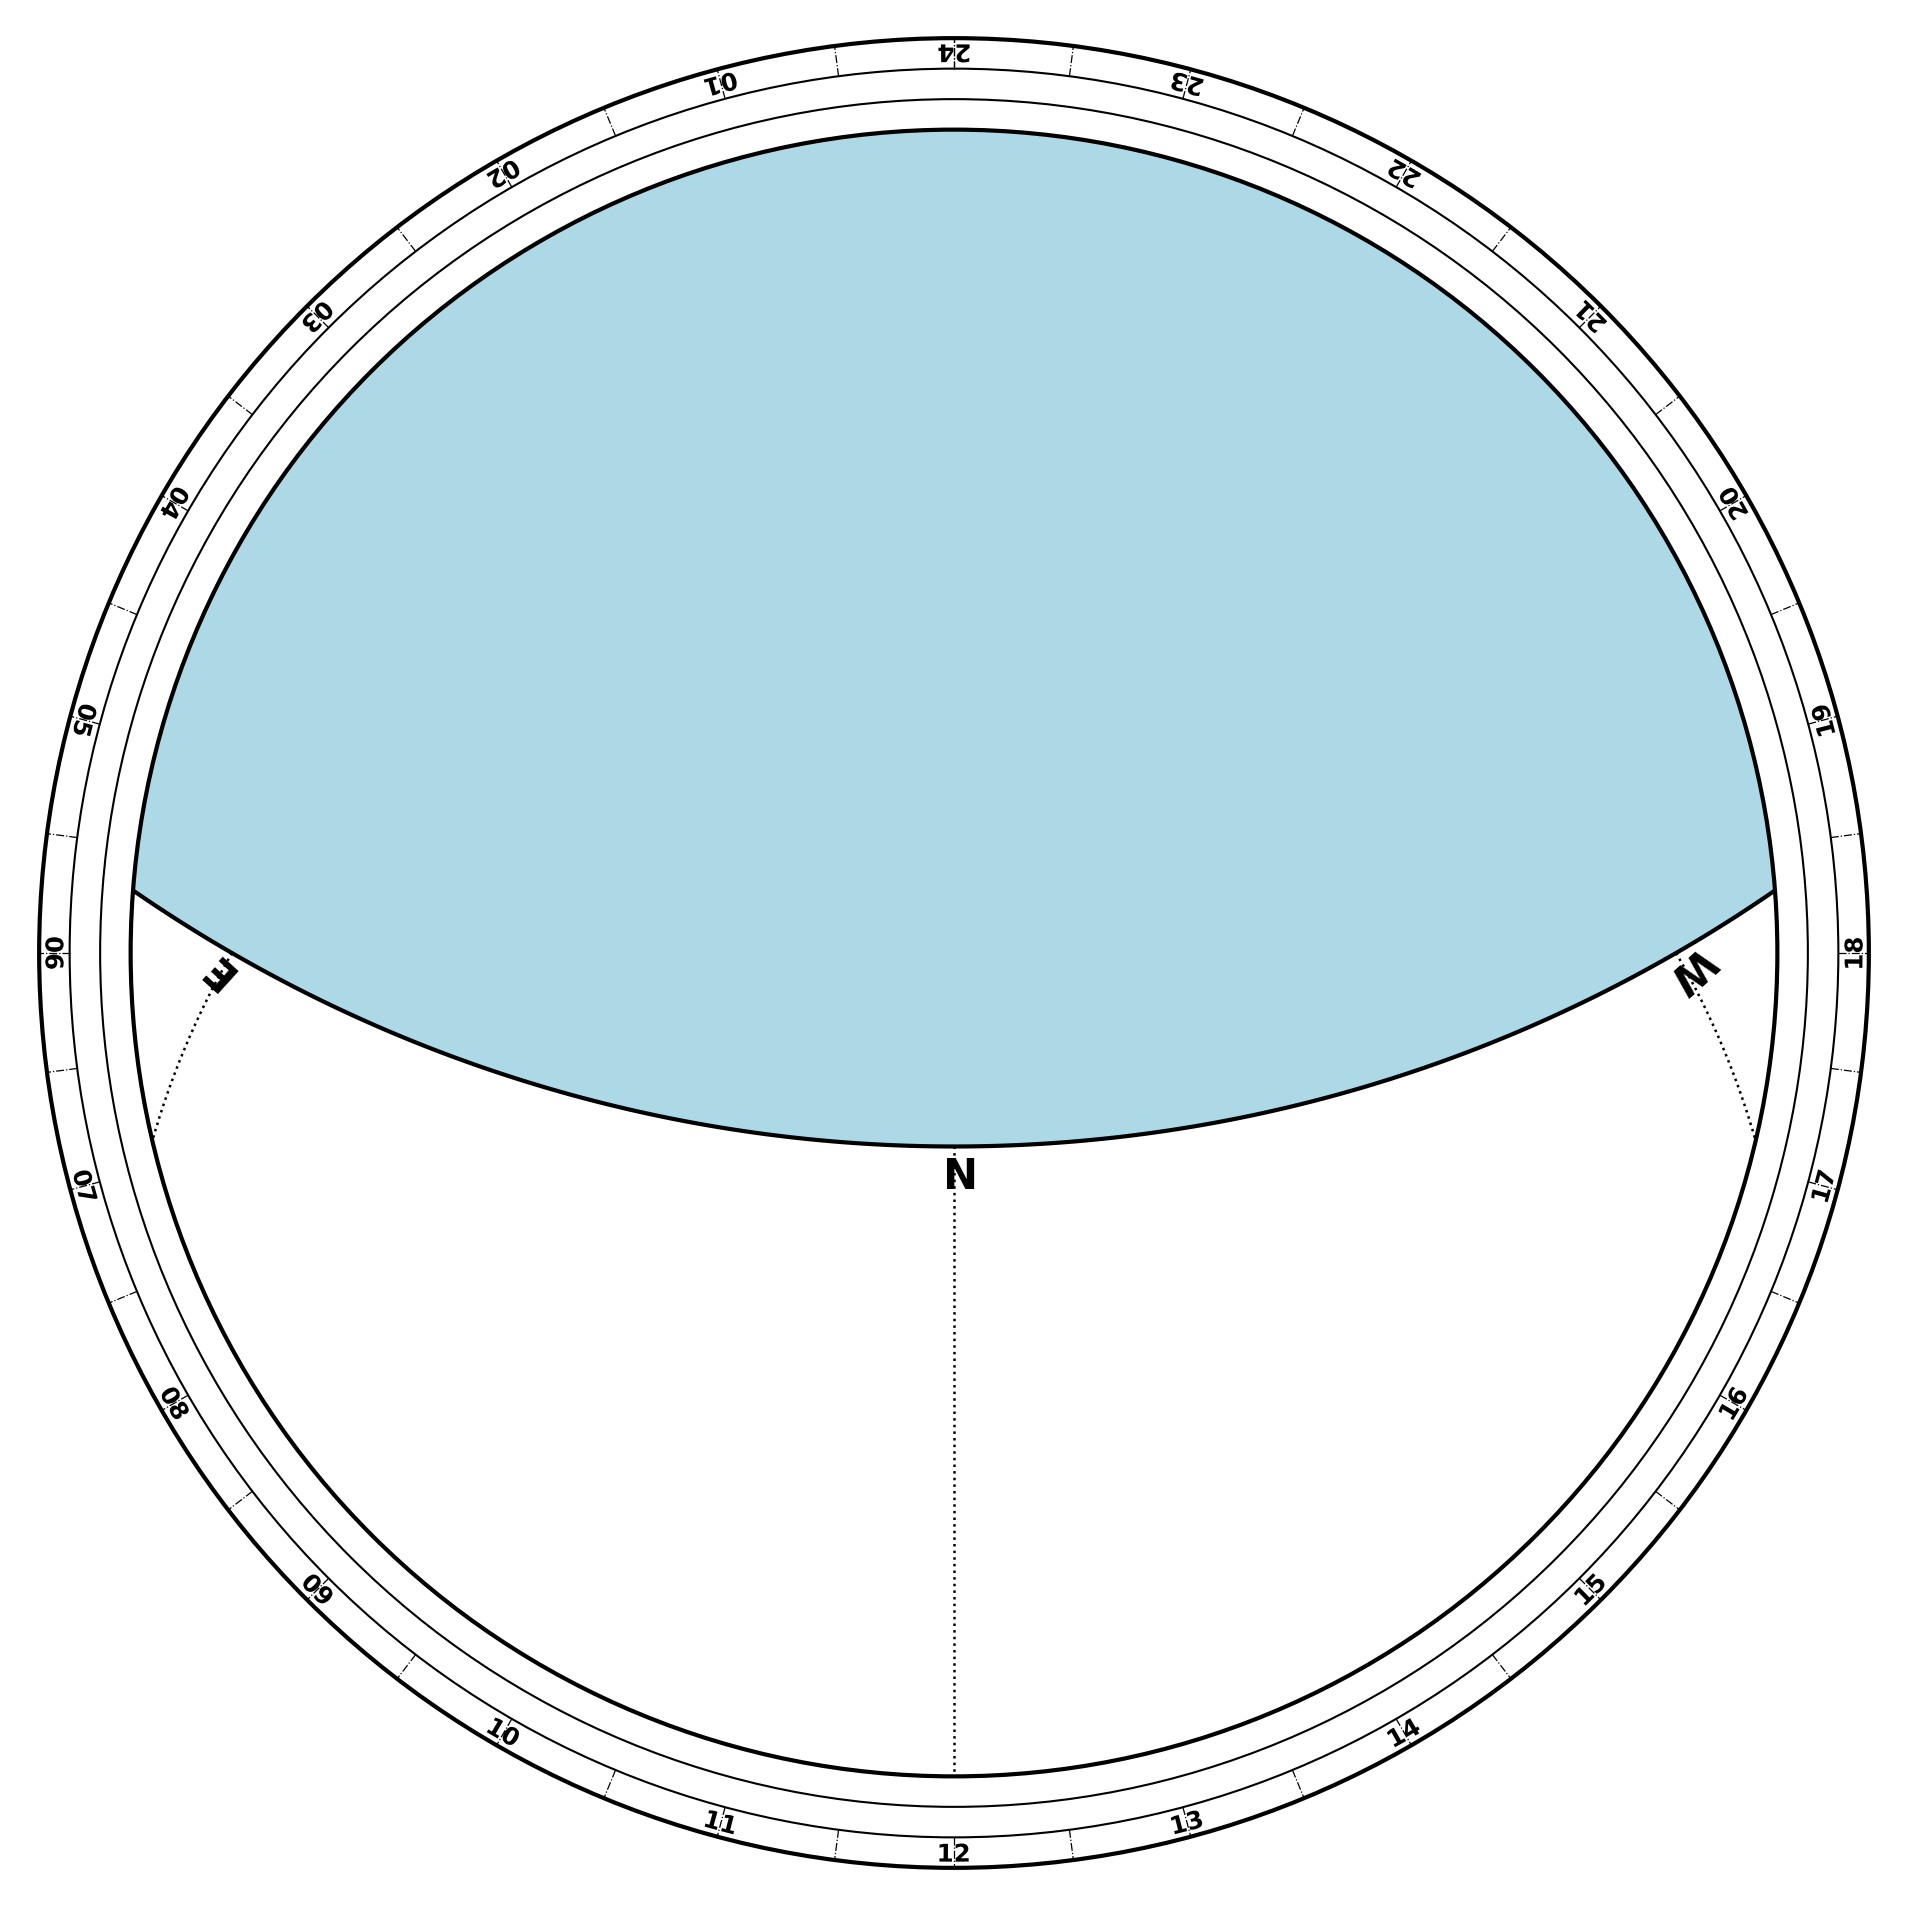

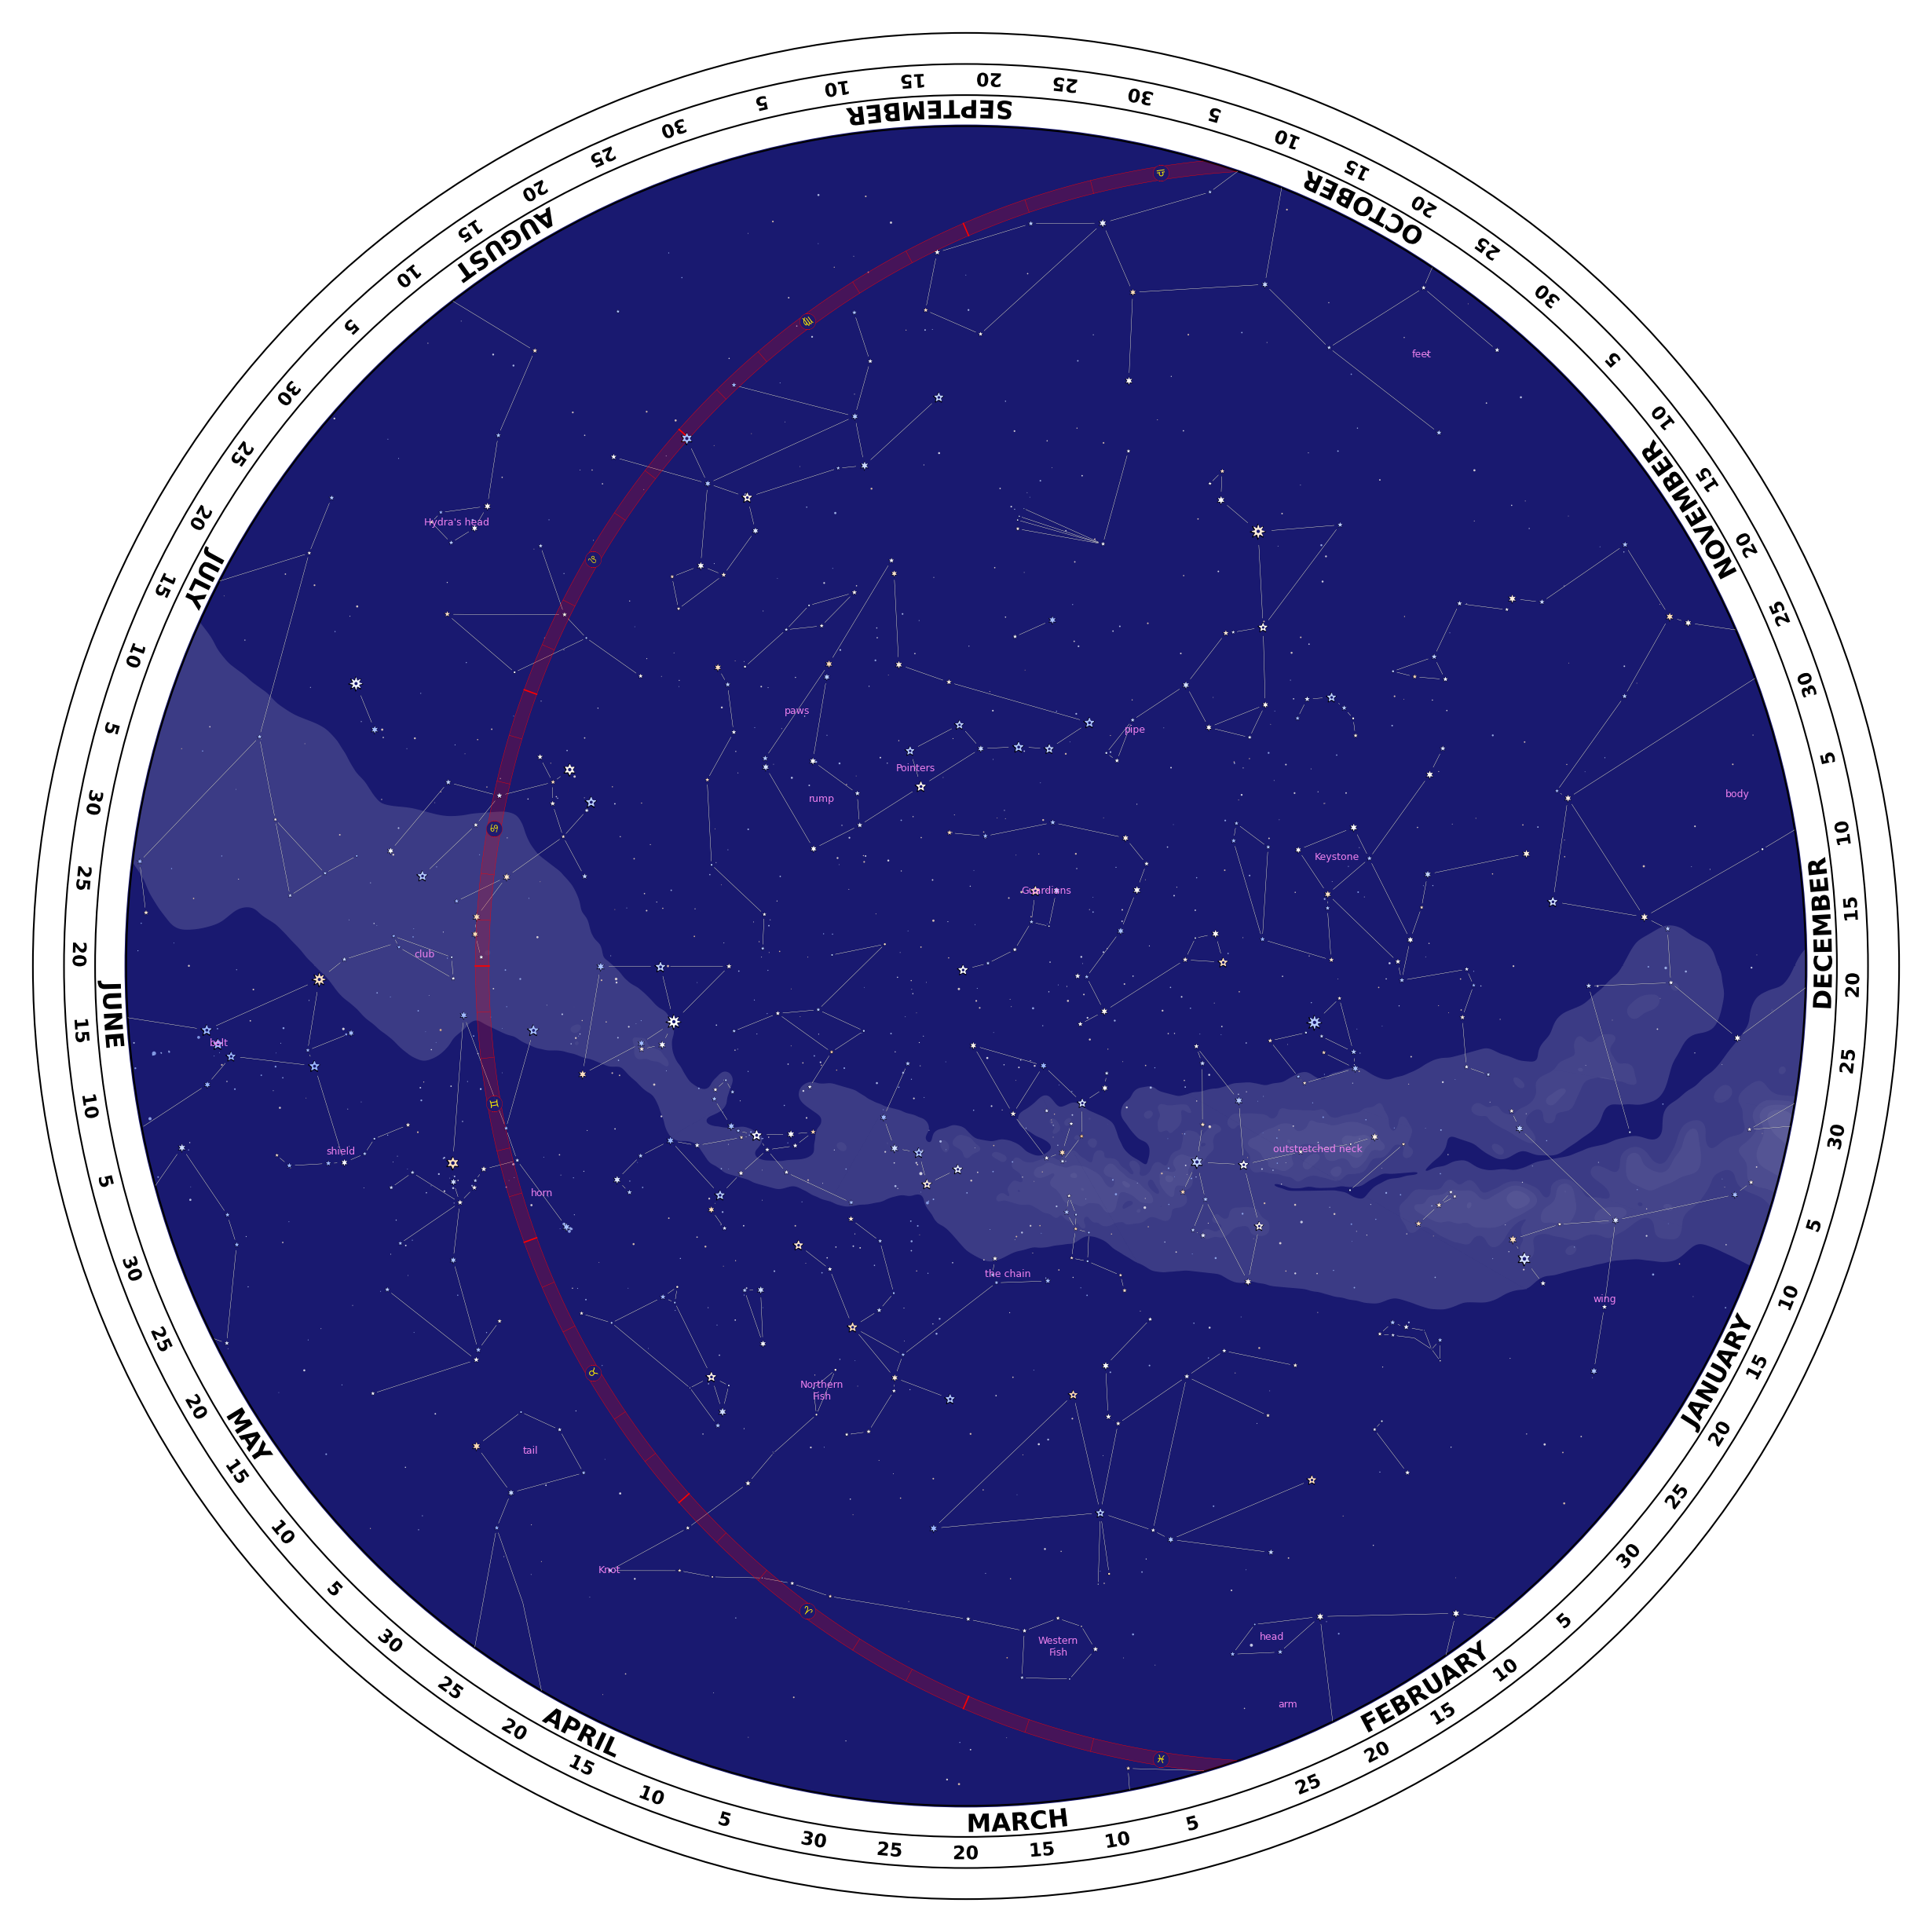

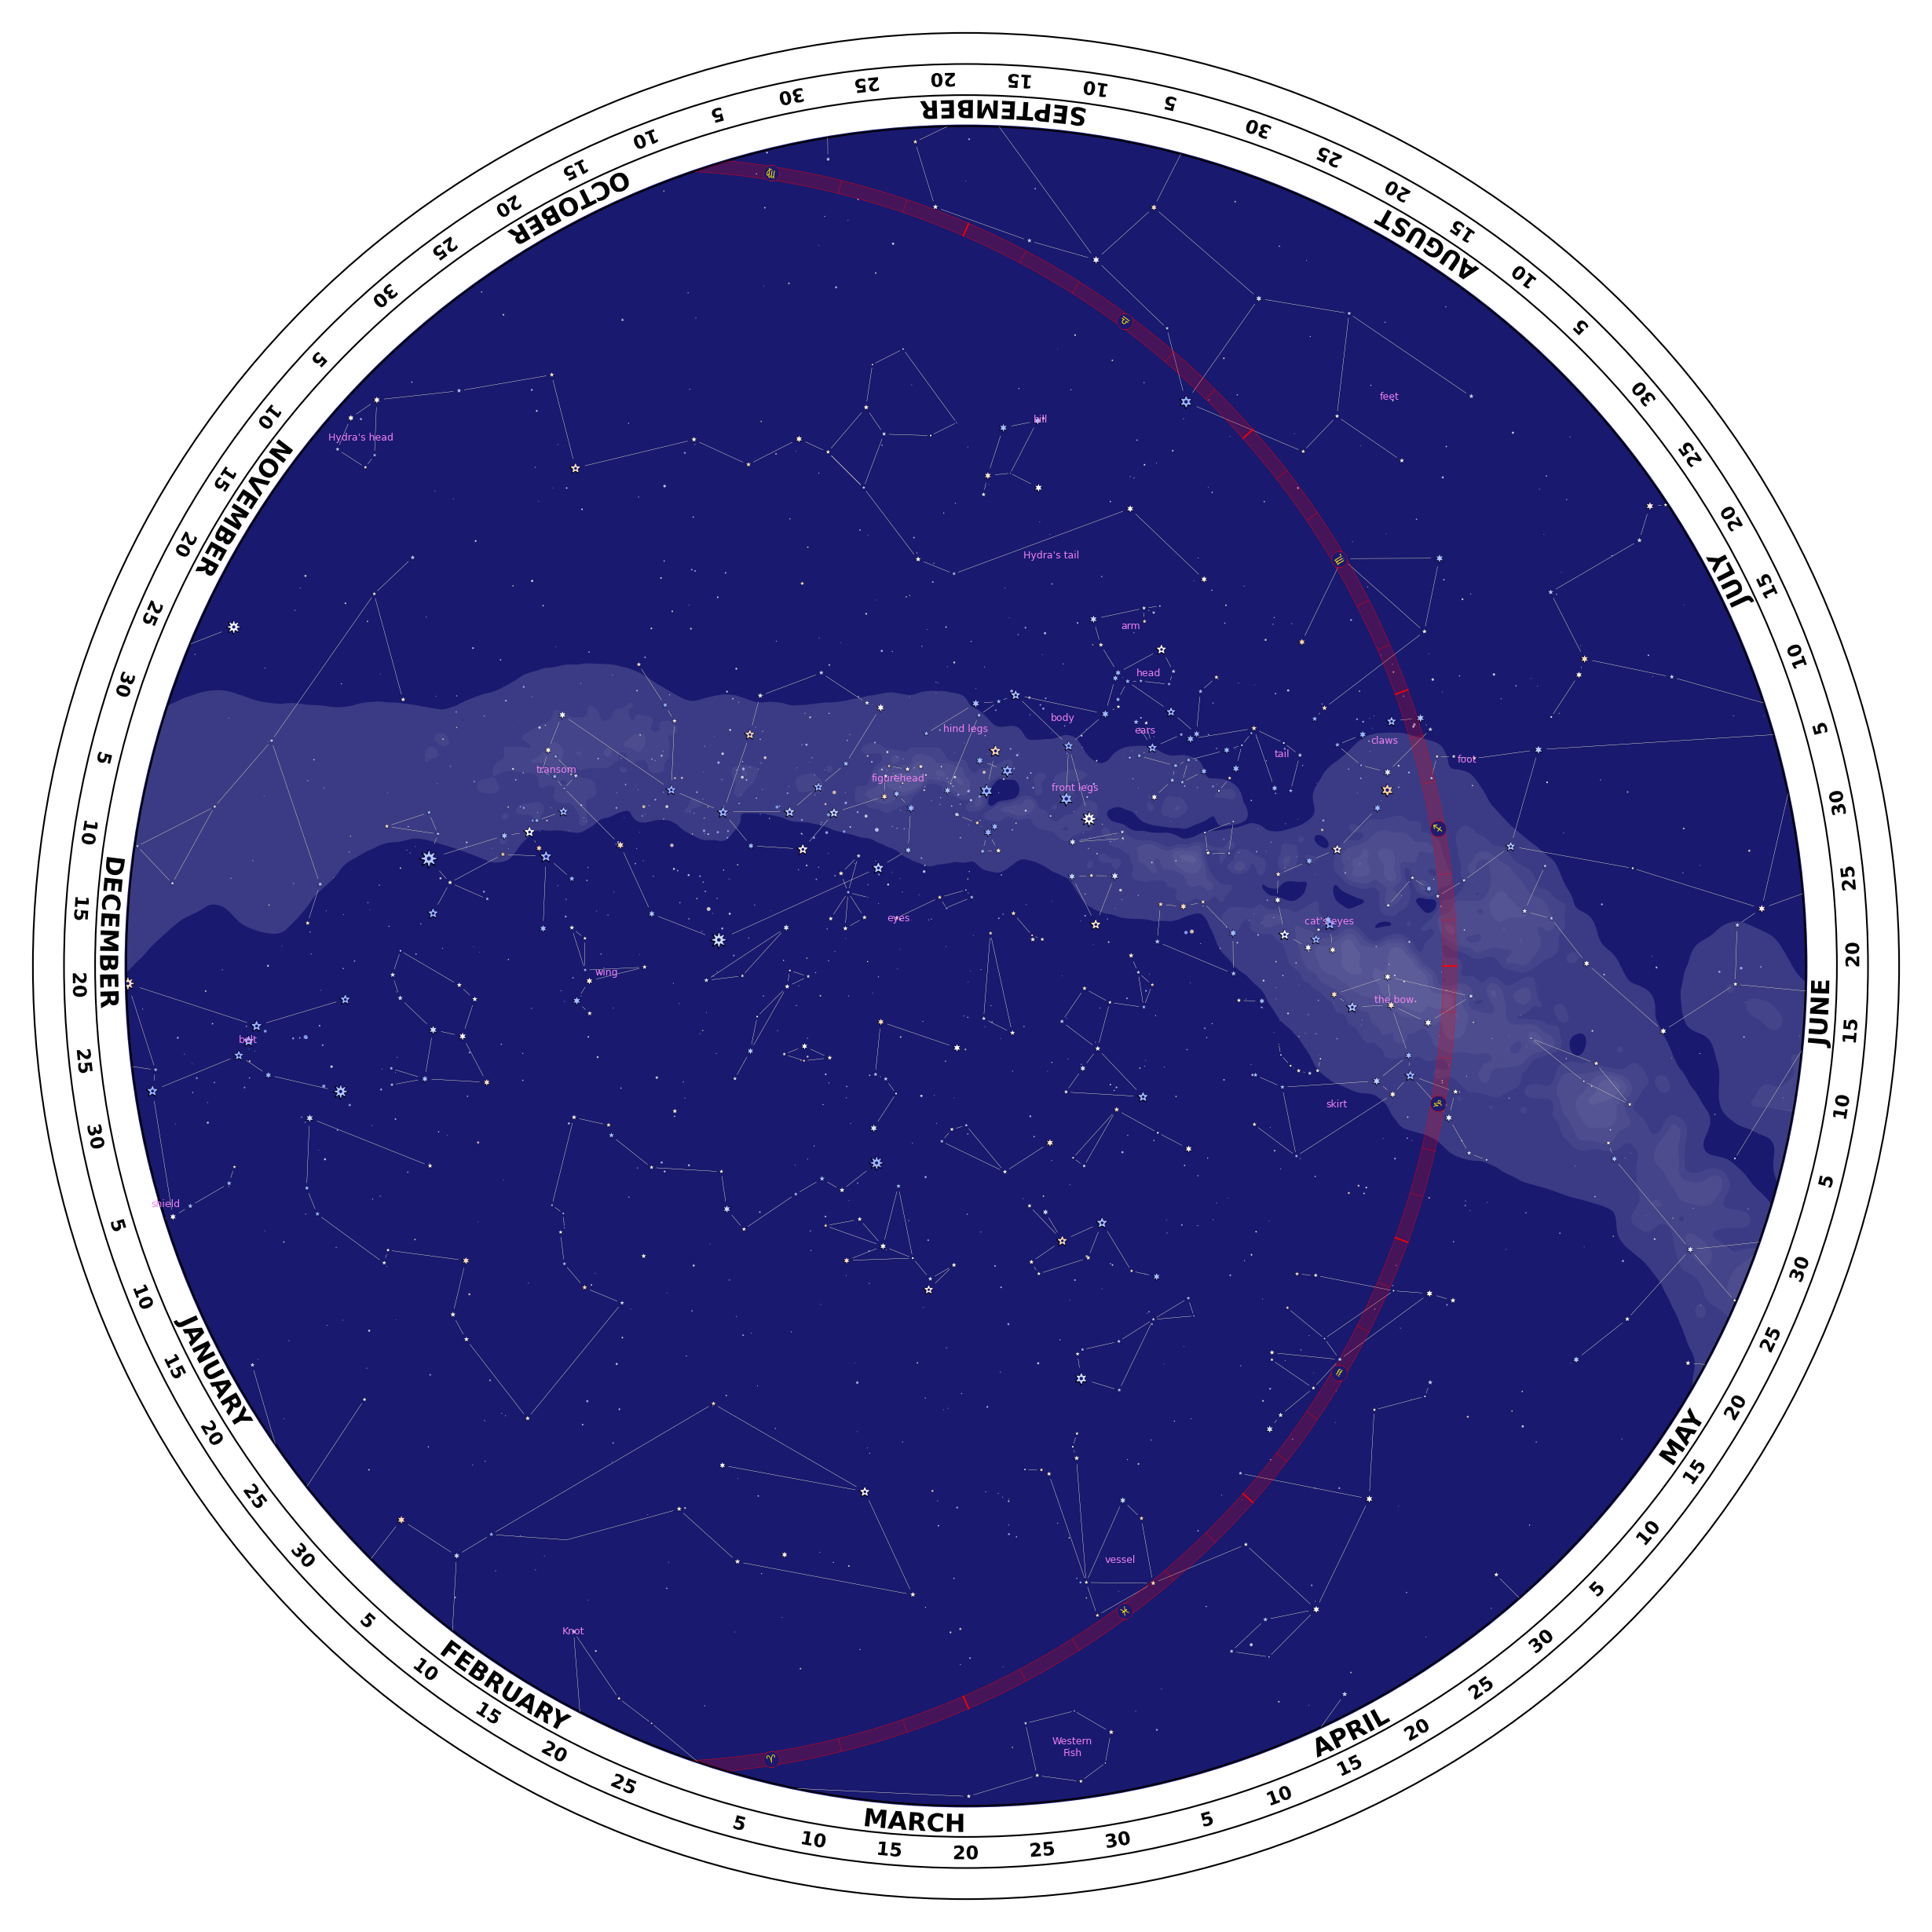

In [7]:
harey.create_planisphere_2sided(lat = '30 S', FOV=195, mode='stereo', SOLID_FILL=True, MARK_CENTER=False)

Let's make a more minimalistic planisphere by changing the color used in plotting.

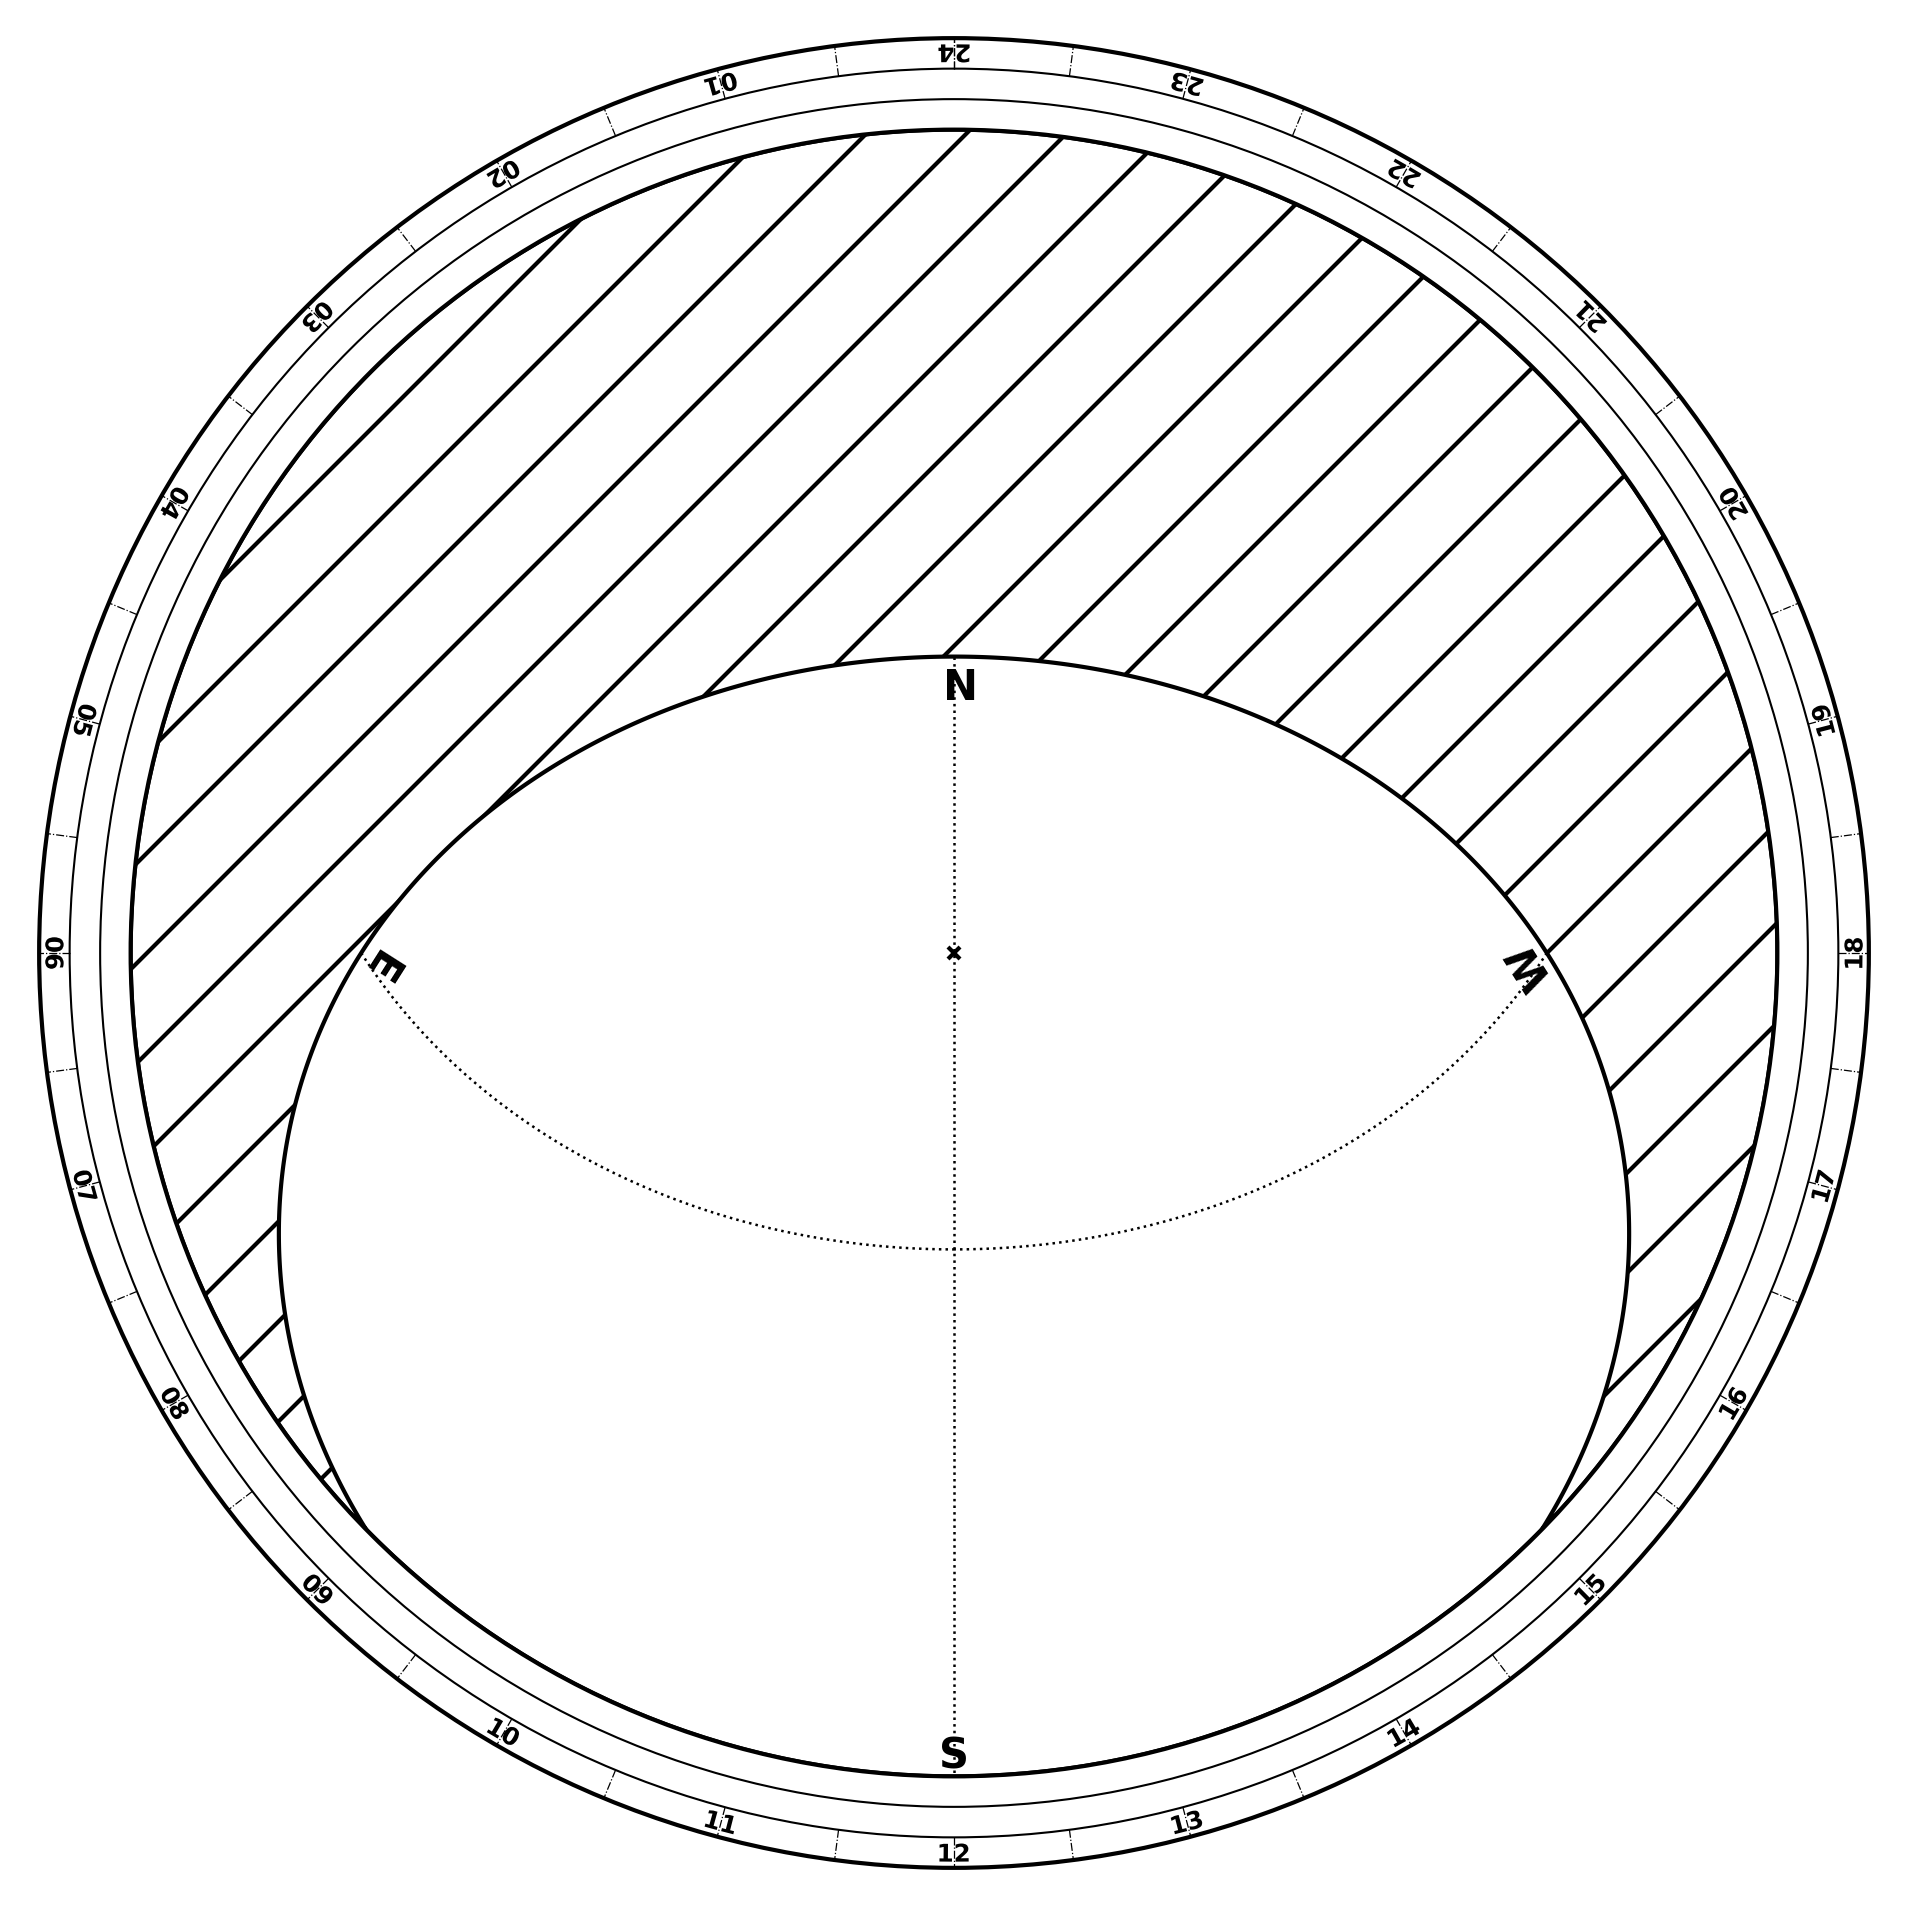

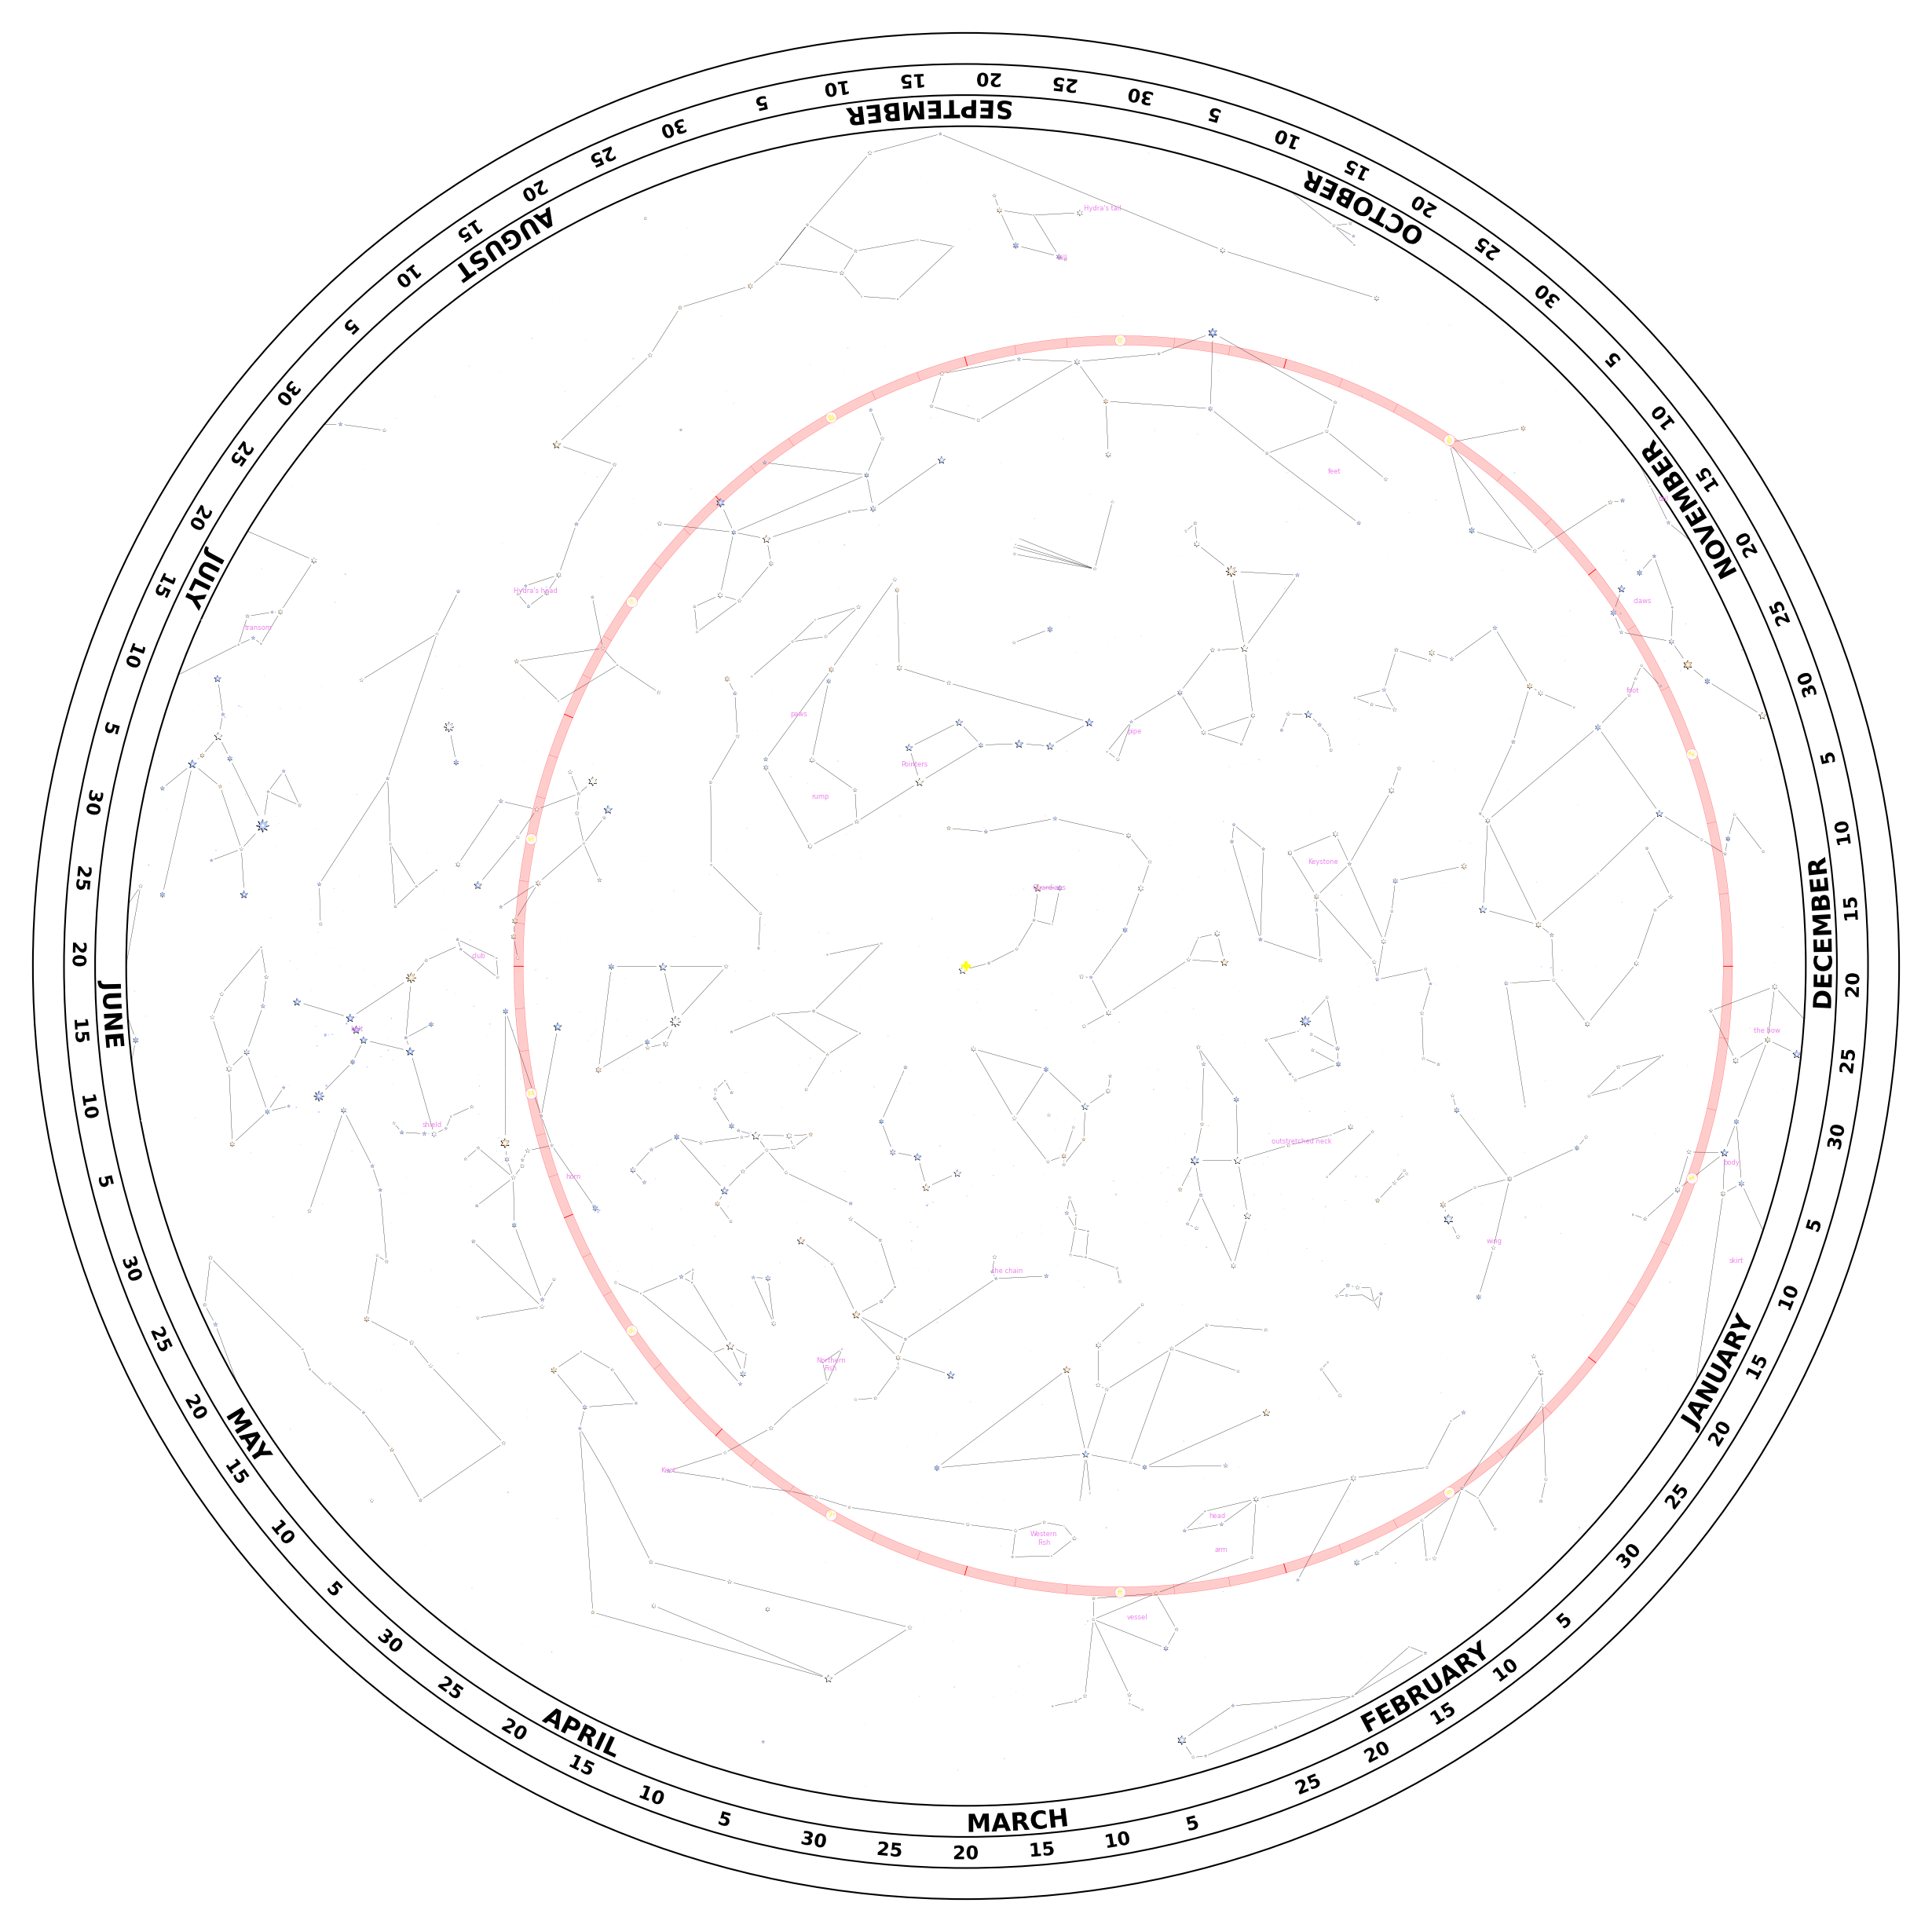

In [9]:
harey.set_colors(sky='white', con_lines='k')
harey.create_planisphere(lat='45 N', save_folder='planisphere', FOV=250)

# How to use it
 Historically, the function of an astrolabe was to measure the elevation of bright stars to compute the local time by having a _mater_ showing many the almucantarats and meridians, and a rete showing only bright constellaions.
 
 Nowadays that we have wonderful things called clocks, most planispheres are used to predict the visible stars at a certain time and date, so the rete got more complex and the mater got simpler.

To use a planisphere, set it for the time and date: rotate the Mater or the polar map until the hour on the inner ring is aligned with the day of the month on the outer ring. Now the stars not covered by the Mater are the ones visible in the sky. To find them, hold the planisphere towards the sky, use the cardinal point to orient yourself and rotate the whole planisphere to align the projected horizon on the mother with the real horizon in the direction chosen. If you have done everything correct, you can now see the constellations in the night sky. 

